# Unified Training Notebook

This notebook wraps `src/train/train.py` and displays saved training visualizations.

Edit the config cell and run all cells.


Select Training Mode：

In [1]:
# User-editable config
DATASET = 'irmas'          # options: chinese, irmas
FEATURE = 'cqt'            # options: mel, cqt, mel_cqt
TASK_MODE = 'single_label' # options: single_label, multi_label
AUTO_GENERATE_MIXED = 'always'  # ask, always, never (only used in Chinese multi-label)
EPOCHS = 11
BATCH_SIZE = 16
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 12
DROPOUT = 0.6
VAL_FRAC = 0.2
SEED = 1337
NUM_WORKERS = 0
THRESHOLD = 0.5
RESUME = False
RUN_NAME = None  # None -> auto naming
WEIGHTS_DIR = None  # Optional absolute/relative path override


In [2]:
import shlex
import os
import subprocess
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'src').exists() and (candidate / 'makefile').exists():
            return candidate
    raise RuntimeError('Cannot locate repo root from current notebook working directory.')

def default_run_name(dataset: str, feature: str, task_mode: str) -> str:
    prefix = 'Chinese' if dataset == 'chinese' else 'IRMAS'
    return f'{prefix}_{feature}_{task_mode}_v1'

def run_stream(cmd, cwd: Path, env: dict) -> None:
    proc = subprocess.Popen(
        cmd,
        cwd=str(cwd),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=0,
    )
    assert proc.stdout is not None
    for raw in iter(proc.stdout.readline, b''):
        line = raw.decode('utf-8', errors='replace')
        print(line, end='')
    ret = proc.wait()
    if ret != 0:
        raise subprocess.CalledProcessError(ret, cmd)

repo_root = find_repo_root(Path.cwd())
python_exec = sys.executable
env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'
env['PYTHONUTF8'] = '1'
env['PYTHONIOENCODING'] = 'utf-8'

resolved_run_name = RUN_NAME or default_run_name(DATASET, FEATURE, TASK_MODE)
if WEIGHTS_DIR:
    p = Path(WEIGHTS_DIR)
    resolved_ckpt_dir = p if p.is_absolute() else (repo_root / p).resolve()
else:
    resolved_ckpt_dir = (repo_root / 'src' / 'models' / 'saved_weights' / resolved_run_name).resolve()

cmd = [
    python_exec,
    '-u',
    'src/train/train.py',
    '--dataset', DATASET,
    '--feature', FEATURE,
    '--task_mode', TASK_MODE,
    '--auto_generate_mixed', AUTO_GENERATE_MIXED,
    '--epochs', str(EPOCHS),
    '--batch_size', str(BATCH_SIZE),
    '--lr', str(LR),
    '--weight_decay', str(WEIGHT_DECAY),
    '--patience', str(PATIENCE),
    '--dropout', str(DROPOUT),
    '--val_frac', str(VAL_FRAC),
    '--seed', str(SEED),
    '--num_workers', str(NUM_WORKERS),
    '--threshold', str(THRESHOLD),
]
if RUN_NAME:
    cmd.extend(['--run_name', RUN_NAME])
if WEIGHTS_DIR:
    cmd.extend(['--weights_dir', str(WEIGHTS_DIR)])
if RESUME:
    cmd.append('--resume')

print('Repo root:', repo_root)
print('Run name:', resolved_run_name)
print('Checkpoint dir:', resolved_ckpt_dir)
print('Running:', ' '.join(shlex.quote(x) for x in cmd))
run_stream(cmd, cwd=repo_root, env=env)


Repo root: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound
Run name: IRMAS_cqt_single_label_v1
Checkpoint dir: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound\src\models\saved_weights\IRMAS_cqt_single_label_v1
Running: 'd:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound\.venv\Scripts\python.exe' -u src/train/train.py --dataset irmas --feature cqt --task_mode single_label --auto_generate_mixed always --epochs 11 --batch_size 16 --lr 0.0001 --weight_decay 0.0001 --patience 12 --dropout 0.6 --val_frac 0.2 --seed 1337 --num_workers 0 --threshold 0.5
Repo root: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound
Loaded 11 classes: cel, cla, flu, gac, gel, org, pia, sax, tru, vio, voi
Starting fresh (no resume).
Training mode: dataset=irmas, feature=cqt, task_mode=single_label, backbone=densenet121, run=IRMAS_cqt_single_label_v1
[1/11] Loss: 2.1571/1.8666 | Val Acc: 0.3990 | Val MacroF1: 0.3633 | Time: 21.3s
[2/

Visualization target feature: CQT
Curve PNG: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound\src\models\saved_weights\IRMAS_cqt_single_label_v1\training_curves_cqt_single_label.png
History CSV: D:\qingchaolaopian\Instrument Sound\GitHub\ml-based-analysis-of-sound\src\models\saved_weights\IRMAS_cqt_single_label_v1\training_history_cqt_single_label.csv


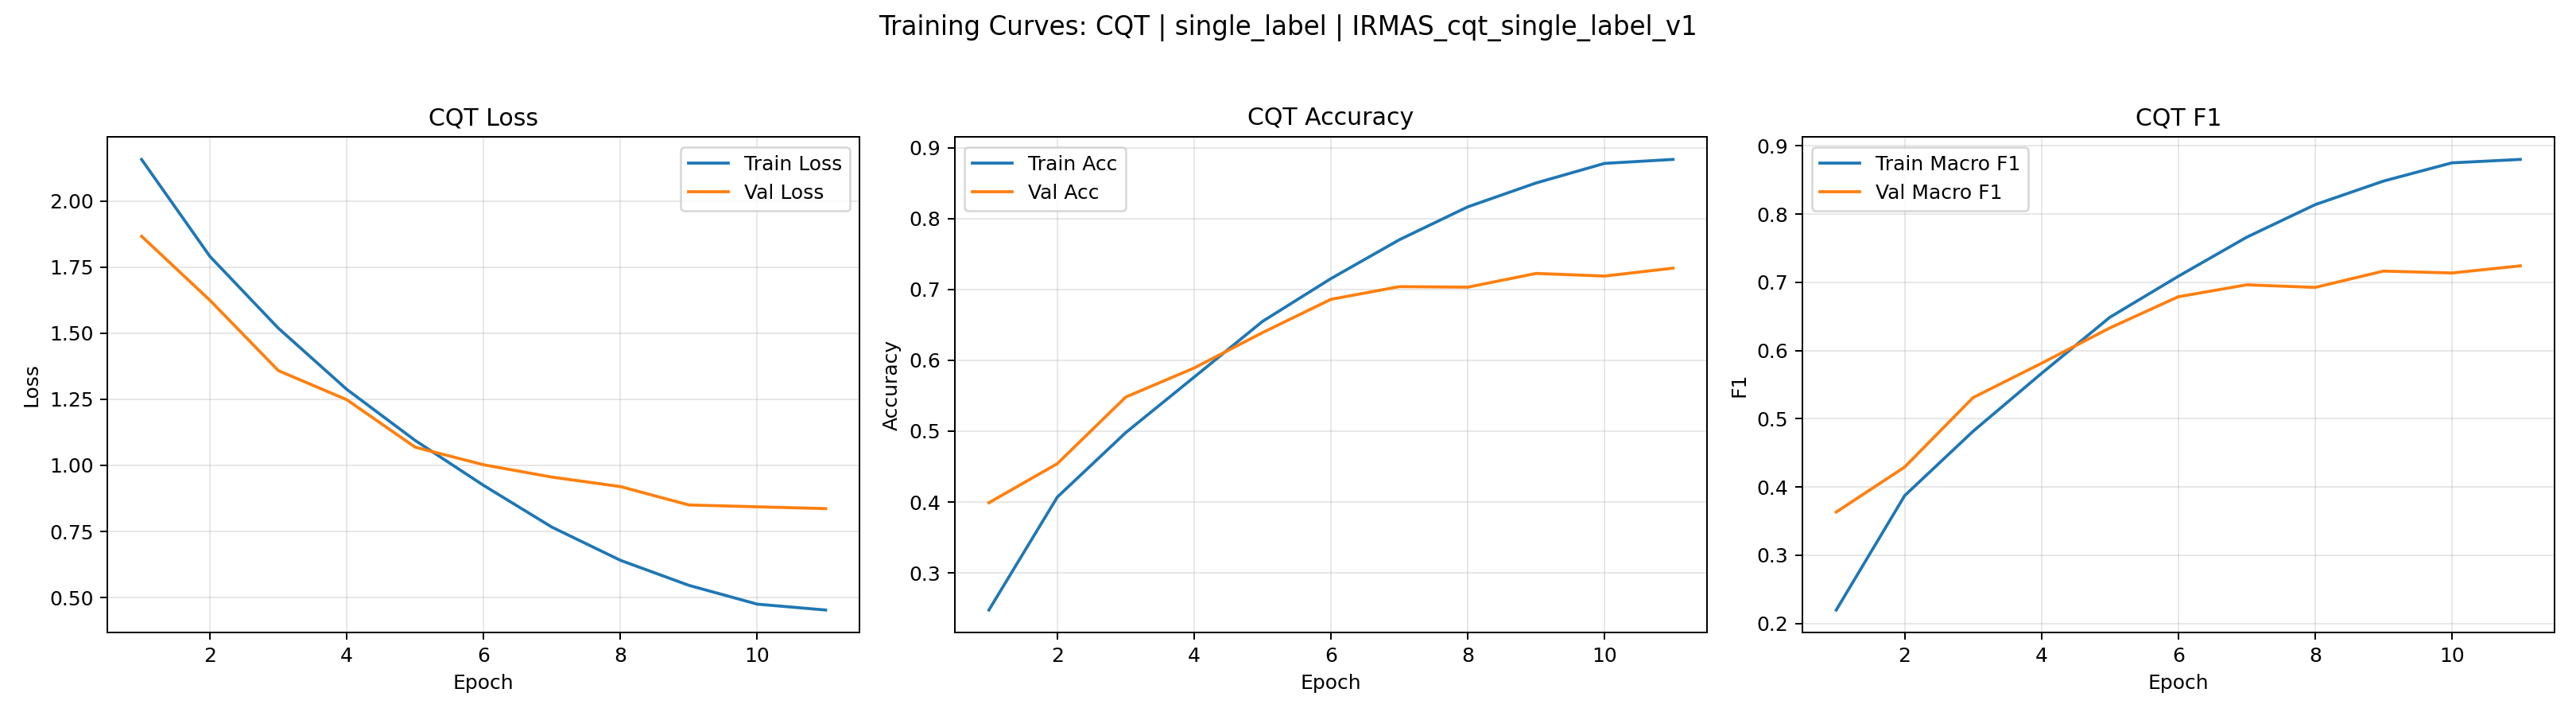


Last 5 epochs:


,train_loss,val_loss,train_acc,val_acc,train_macro_f1,val_macro_f1
6,0.766224,0.955558,0.770134,0.703952,0.766226,0.696448
7,0.640935,0.919817,0.816555,0.703207,0.813933,0.692625
8,0.546320,0.850290,0.850298,0.722595,0.848532,0.716565
9,0.475185,0.843289,0.877890,0.718867,0.875246,0.713802
10,0.452953,0.836513,0.883482,0.730052,0.880259,0.724217


In [3]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

feature_name = {'mel': 'Mel', 'cqt': 'CQT', 'mel_cqt': 'Mel + CQT'}.get(FEATURE, FEATURE)
curve_png = resolved_ckpt_dir / f'training_curves_{FEATURE}_{TASK_MODE}.png'
history_csv = resolved_ckpt_dir / f'training_history_{FEATURE}_{TASK_MODE}.csv'

print(f'Visualization target feature: {feature_name}')
print('Curve PNG:', curve_png)
print('History CSV:', history_csv)

if curve_png.exists():
    display(Image(filename=str(curve_png)))
else:
    print('[WARN] Training curve image not found. Check the training logs for errors.')

if history_csv.exists():
    hist = pd.read_csv(history_csv)
    print('\nLast 5 epochs:')
    display(hist.tail(5))
else:
    print('[WARN] Training history CSV not found.')
